# Independent ESN wipe research — Mac execution + frozen-UnifoLM teacher workflow

This is the revised architecture: the task-specific ESN receives only $[q_t,\dot q_t]$ and runs closed-loop at 100 Hz. Frozen UnifoLM is a training-time teacher at 570 ms anchors, never a deployment input. Ridge behavior cloning is only initialization; MuJoCo task optimization uses black-box policy search.

The notebook refuses to describe demonstration proxies or mock inference as final teacher labels.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
ROOT=Path.cwd().parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
MJCF=ROOT/'unitree_mujoco/unitree_robots/g1/g1_29dof.xml'
RESULTS=ROOT/'results/main_independent_esn'; RESULTS.mkdir(parents=True,exist_ok=True)
from wipe_esn_experiment import ESN,fit_bc_initializer,pack_episodes,rollout
from unifolm_teacher_pipeline import mac_capability_report,save_visited_bundle,validate_cache
mac_capability_report()

/Users/andrew/Library/Mobile Documents/com~apple~CloudDocs/Desktop/devops-sre/myjarvis/robotics/research/notebooks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'platform': 'macOS-26.4-arm64-arm-64bit-Mach-O',
 'machine': 'arm64',
 'torch': '2.13.0',
 'mps_built': True,
 'mps_available': True,
 'cuda_available': False,
 'mujoco': '3.12.0',
 'unifolm_official_local_supported': False,
 'reason': 'Official UnifoLM release requires Python 3.10/CUDA 12.4/FlashAttention2.'}

## 1. Mac capability decision

The Apple M5/32 GB Mac runs MuJoCo and PyTorch Metal. Unitree's official UnifoLM release targets Python 3.10, CUDA 12.4 and FlashAttention2; the real action-head runtime is therefore a CUDA-worker stage. Collection, ESN fitting, MuJoCo optimization, cache validation, and 23-D EE→29-D IK all run here.

In [2]:
ds=load_dataset('unitreerobotics/G1_Dex1_Wipe_Table')
TRAIN_EPS=[0,1,2,3]; HELDOUT_EPS=[160,161,162]
episodes=pack_episodes(ds['train'],TRAIN_EPS+HELDOUT_EPS)
esn=ESN(n=116,seed=0)
fit_bc_initializer(esn,{ep:episodes[ep] for ep in TRAIN_EPS})

{'samples': 5422,
 'demo_hz': 30.0,
 'controller_hz': 100.0,
 'target_semantics': 'next recorded demo configuration'}

## 2. Collect teacher observations from states the ESN actually visits

Each 570 ms anchor stores rendered RGB, the visited 29-D joint state and velocity, and validated 23-D EE proprioception. Re-run collection after every accepted policy update (DAgger-style), then label that new bundle on the frozen CUDA teacher.

In [3]:
bundle=RESULTS/'visited_ep0_seed0.npz'
if not bundle.exists():
    result=rollout(esn,episodes[0],MJCF,capture_anchors=True)
    save_visited_bundle(result['captures'],bundle,episode=0,seed=0)
bundle_meta=json.loads(bundle.with_suffix('.json').read_text())
bundle_meta

{'schema': 'unifolm_visited_observations_v1',
 'created_utc': '2026-08-27T02:52:37.887276+00:00',
 'episode': 0,
 'policy_seed': 0,
 'instruction': 'Wipe the water off the table with the cloth.',
 'anchors': 22,
 'rgb_shape': [22, 224, 224, 3],
 'proprio_semantics': '23-D [L_xyz,L_rot6d,R_xyz,R_rot6d,waist5]',
 'teacher_period_s': 0.57}

## 3. Frozen UnifoLM + full-pose IK labeling

Run this exact command in the official UnifoLM Python-3.10/CUDA-12.4 environment on the lab worker:

```bash
PYTHONPATH=/path/to/research python notebooks/unifolm_teacher_pipeline.py label \
  results/main_independent_esn/visited_ep0_seed0.npz \
  results/main_independent_esn/teacher_ep0_seed0.npz \
  --mjcf unitree_mujoco/unitree_robots/g1/g1_29dof.xml \
  --model unitreerobotics/UnifoLM-VLA-Base --unnorm-key g1_wipe_table
```

The labeler sets `allow_mock_fallback=False`, sends RGB + language + 23-D visited-state proprioception to frozen UnifoLM, converts its 23-D action through position-and-orientation Jacobian IK, and writes 29-D joint anchors.

In [4]:
teacher_cache=RESULTS/'teacher_ep0_seed0.npz'
teacher_ready=teacher_cache.exists()
teacher_status=validate_cache(teacher_cache,expected_anchors=bundle_meta['anchors']) if teacher_ready else {'ready':False,'blocker':'Official frozen-UnifoLM cache must be produced on CUDA worker; mock/proxy labels are forbidden.'}
teacher_status

{'ready': False,
 'blocker': 'Official frozen-UnifoLM cache must be produced on CUDA worker; mock/proxy labels are forbidden.'}

## 4. IK acceptance test

The prior adapter silently ignored rotation. It now solves a damped 6-D Jacobian problem. The saved held-out test uses simultaneous ±1 cm position and ±5° orientation perturbations and requires p95 error below 5 mm and 2°.

In [5]:
ik_validation=json.loads((RESULTS/'ik_validation.json').read_text())
assert ik_validation['pass']
ik_validation

{'pose_targets': 20,
 'position_perturbation_bound_m': 0.01,
 'orientation_perturbation_bound_deg': 5,
 'mean_position_error_m': 0.0010254754588208356,
 'p95_position_error_m': 0.0011250792268440353,
 'mean_orientation_error_deg': 0.2738638428108585,
 'p95_orientation_error_deg': 0.6680675099195037,
 'pass': True}

## 5. Literature-grounded task objective

Success requires grasp, ≥0.768 m wipe path (5th percentile of all 200 demonstrations), ≥90% geometric table contact, ≥90% bounded tabletop coverage, no joint-limit violation, and no >5 cm mocap cloth jump. Read `results/main_independent_esn/TASK_OBJECTIVE.md` for sources and limitations. Geometric contact is not a calibrated force claim.

In [6]:
print((RESULTS/'TASK_OBJECTIVE.md').read_text())

# Wipe-task objective and validation policy

## Objective used by the experiment

The simulator reports five independently interpretable, dimensionless terms:

1. grasp failure (binary);
2. normalized wipe-path shortfall;
3. normalized table-contact shortfall;
4. normalized target-area coverage shortfall;
5. small smoothness and joint-limit penalties.

The first four terms have equal unit weight after normalization. This avoids
claiming that an arbitrary numerical coefficient is scientifically meaningful.
The sparse frozen-UnifoLM MSE is a separate term and is evaluated only every
570 ms.

Success requires all of:

- a proximity-gated cloth grasp;
- at least **0.768 m** cloth path while grasped (the empirical 5th percentile
  of right-EE closed-gripper path length across all 200
  `G1_Dex1_Wipe_Table` demonstrations; measured locally on 2026-08-26);
- at least **90%** table-contact ratio during the grasped phase;
- coverage of at least **90%** of the declared 0.2016 m² table top; cover

## 6. Multi-seed optimizer comparison on this Mac

The completed run uses three reservoir seeds, random search, SPSA, and CEM with equal eight-candidate budgets, then evaluates episodes 160–162. It contains at least 72 optimization rollouts plus 27 held-out rollouts. Because the real teacher cache is pending, these results are explicitly task-only and are not the final teacher-guided experiment.

To reproduce: `python run_full_mac_experiment.py --budget 8 --seeds 0,1,2`.

In [7]:
benchmark=json.loads((RESULTS/'mac_optimizer_benchmark.json').read_text())
summary={}
for method in benchmark['methods']:
    rows=[r for r in benchmark['rows'] if r['method']==method]
    summary[method]={'heldout_L_task_mean':float(np.mean([r['heldout_L_task'] for r in rows])),'grasps':sum(r['grasp_success'] for r in rows),'successes':sum(r['task_success'] for r in rows),'trials':len(rows)}
summary

{'random': {'heldout_L_task_mean': 3.619292982748221,
  'grasps': 2,
  'successes': 0,
  'trials': 9},
 'spsa': {'heldout_L_task_mean': 4.134715560813998,
  'grasps': 0,
  'successes': 0,
  'trials': 9},
 'cem': {'heldout_L_task_mean': 3.9216024650438737,
  'grasps': 1,
  'successes': 0,
  'trials': 9}}

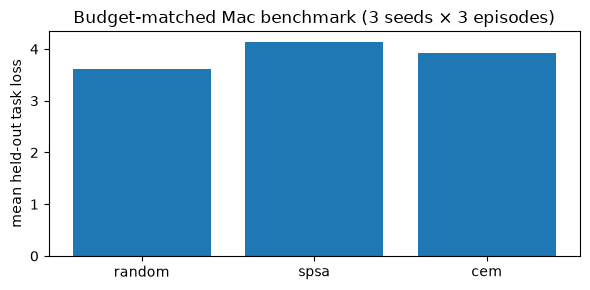

In [8]:
methods=list(summary); losses=[summary[m]['heldout_L_task_mean'] for m in methods]
fig,ax=plt.subplots(figsize=(6,3)); ax.bar(methods,losses); ax.set_ylabel('mean held-out task loss'); ax.set_title('Budget-matched Mac benchmark (3 seeds × 3 episodes)'); fig.tight_layout(); plt.show()

## 7. Final teacher-guided DAgger cycle

After the CUDA label file arrives: load `joint_target_29d`, optimize with teacher weight enabled, collect a fresh visited-state bundle from the updated policy, relabel it, and repeat until validation stops improving. Report all seeds, component losses, success confidence intervals, and the 80/90/95% threshold sensitivity analysis.

Current honest result: the Mac pipeline is operational, full-pose IK passes, and the optimizer comparison completed, but **0/27 held-out trials met every strict success gate**. Random search produced 2/9 grasps, CEM 1/9, and SPSA 0/9. This is a negative result—not evidence that the independent ESN solves wiping without the real teacher.